# Assignment 3: Speech Emotion Classification

**Allan | Student ID: 301635245**

This notebook follows the course workflow: extract chroma, mel-spectrogram, and MFCC features from each audio file; split RAVDESS into training and test sets; compare unscaled and scaled features with classic classifiers; then evaluate the RAVDESS-trained models on my Actor 25 recordings.

## Data and setup

The RAVDESS speech folders should be under `Audio Data/Actor_01` to `Actor_24`. My recordings should be under `My Voice/Actor_25`. Audio is not committed to this public repository. File labels are read from the third field of each RAVDESS-style filename (01 neutral, 02 calm, 03 happy, 04 sad, 05 angry, 06 fearful, 07 disgust, 08 surprised). Actor 25 is male. The same 80/20 split is used for every feature version. Scalers are fitted only on the RAVDESS training rows and then applied to both test sets.

In [1]:
from pathlib import Path
import glob
import os
import warnings

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

warnings.filterwarnings('ignore')
RAVDESS_DIR = Path('Audio Data')
MY_VOICE_DIR = Path('My Voice/Actor_25')
Path('results').mkdir(exist_ok=True)

emotion_names = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}
emotion_order = list(emotion_names.values())
ravdess_files = sorted(RAVDESS_DIR.glob('Actor_*/*.wav'))
my_audio_files = sorted(MY_VOICE_DIR.glob('*.wav'))
print(f'RAVDESS audio files: {len(ravdess_files)}')
print(f'Actor 25 audio files: {len(my_audio_files)}')
if not ravdess_files or not my_audio_files:
    raise FileNotFoundError('Check the Audio Data and My Voice folder locations above.')

RAVDESS audio files: 1440
Actor 25 audio files: 60


## Feature extraction

For each recording, I average the frame-level features into one vector: 12 chroma + 128 mel bands + 40 MFCC = 180 features. Stereo recordings are converted to mono, matching the tutorial.

In [2]:
def get_features(file_path):
    waveform, sample_rate = sf.read(file_path, dtype='float32')
    if waveform.ndim > 1:
        waveform = librosa.to_mono(waveform.T)

    stft = np.abs(librosa.stft(waveform))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sample_rate).mean(axis=1)
    mel = librosa.feature.melspectrogram(
        y=waveform, sr=sample_rate, n_mels=128, fmax=8000
    ).mean(axis=1)
    mfcc = librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=40).mean(axis=1)
    return np.hstack((chroma, mel, mfcc))


def emotion_from_filename(file_path):
    code = Path(file_path).stem.split('-')[2]
    return emotion_names[code]


def load_dataset(files, name):
    X, y = [], []
    for i, file_path in enumerate(files, start=1):
        X.append(get_features(file_path))
        y.append(emotion_from_filename(file_path))
        if i % 200 == 0 or i == len(files):
            print(f'{name}: processed {i}/{len(files)} files')
    return np.asarray(X), np.asarray(y)


X_ravdess, y_ravdess = load_dataset(ravdess_files, 'RAVDESS')
X_actor25, y_actor25 = load_dataset(my_audio_files, 'Actor 25')
print('Feature matrix shapes:', X_ravdess.shape, X_actor25.shape)

RAVDESS: processed 200/1440 files


RAVDESS: processed 400/1440 files


RAVDESS: processed 600/1440 files


RAVDESS: processed 800/1440 files


RAVDESS: processed 1000/1440 files


RAVDESS: processed 1200/1440 files


RAVDESS: processed 1400/1440 files


RAVDESS: processed 1440/1440 files


Actor 25: processed 60/60 files
Feature matrix shapes: (1440, 180) (60, 180)


## Label balance

This is a small check that the filename labels were read as expected before training.

,RAVDESS,Actor 25
neutral,96,4
calm,192,8
happy,192,8
sad,192,8
angry,192,8
fearful,192,8
disgust,192,8
surprised,192,8


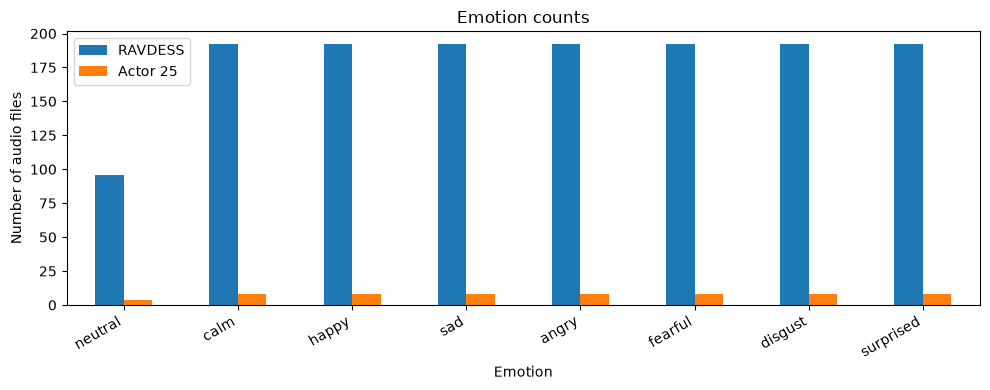

In [3]:
label_counts = pd.DataFrame({
    'RAVDESS': pd.Series(y_ravdess).value_counts().reindex(emotion_order, fill_value=0),
    'Actor 25': pd.Series(y_actor25).value_counts().reindex(emotion_order, fill_value=0)
})
display(label_counts)
label_counts.to_csv('results/label_counts.csv')

ax = label_counts.plot(kind='bar', figsize=(10, 4), color=['#1f77b4', '#ff7f0e'])
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of audio files')
ax.set_title('Emotion counts')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('results/label_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature values and scaling

The three feature groups have different numeric ranges. The table below compares raw RAVDESS and Actor 25 features, then shows the range of Actor 25 after each scaler is learned from the RAVDESS training set. External values can fall outside the training range after MinMax scaling.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_ravdess, y_ravdess, test_size=0.2, random_state=42
)
standard_scaler = StandardScaler().fit(X_train)
minmax_scaler = MinMaxScaler().fit(X_train)

feature_groups = {
    'Chroma (12)': slice(0, 12),
    'Mel (128)': slice(12, 140),
    'MFCC (40)': slice(140, 180)
}
feature_summary = []
for group, section in feature_groups.items():
    for dataset_name, values in [('RAVDESS', X_ravdess), ('Actor 25', X_actor25)]:
        block = values[:, section]
        feature_summary.append({
            'Dataset': dataset_name, 'Feature group': group,
            'Mean': block.mean(), 'Std': block.std(),
            'Min': block.min(), 'Max': block.max()
        })
display(pd.DataFrame(feature_summary).round(4))
pd.DataFrame(feature_summary).round(4).to_csv('results/feature_summary.csv', index=False)

scaled_actor25 = {
    'Unscaled': X_actor25,
    'Standard': standard_scaler.transform(X_actor25),
    'MinMax': minmax_scaler.transform(X_actor25)
}
scale_summary = []
for name, values in scaled_actor25.items():
    scale_summary.append({
        'Actor 25 version': name,
        'Overall mean': values.mean(), 'Overall std': values.std(),
        'Overall min': values.min(), 'Overall max': values.max()
    })
display(pd.DataFrame(scale_summary).round(4))
pd.DataFrame(scale_summary).round(4).to_csv('results/actor25_scaling_summary.csv', index=False)

,Dataset,Feature group,Mean,Std,Min,Max
0,RAVDESS,Chroma (12),0.6660,0.085400,0.310400,0.874100
1,Actor 25,Chroma (12),0.7073,0.038900,0.586600,0.820400
2,RAVDESS,Mel (128),0.1869,1.597300,0.000000,149.208298
3,Actor 25,Mel (128),0.0192,0.054900,0.000000,1.301800
4,RAVDESS,MFCC (40),-14.6348,98.546501,-873.242310,115.125801
5,Actor 25,MFCC (40),-9.4341,89.334602,-588.080688,190.188400


,Actor 25 version,Overall mean,Overall std,Overall min,Overall max
0,Unscaled,-2.0357,42.298401,-588.080688,190.188400
1,Standard,0.0589,1.444000,-2.905500,36.126999
2,MinMax,0.1581,0.287700,-0.078500,4.471600


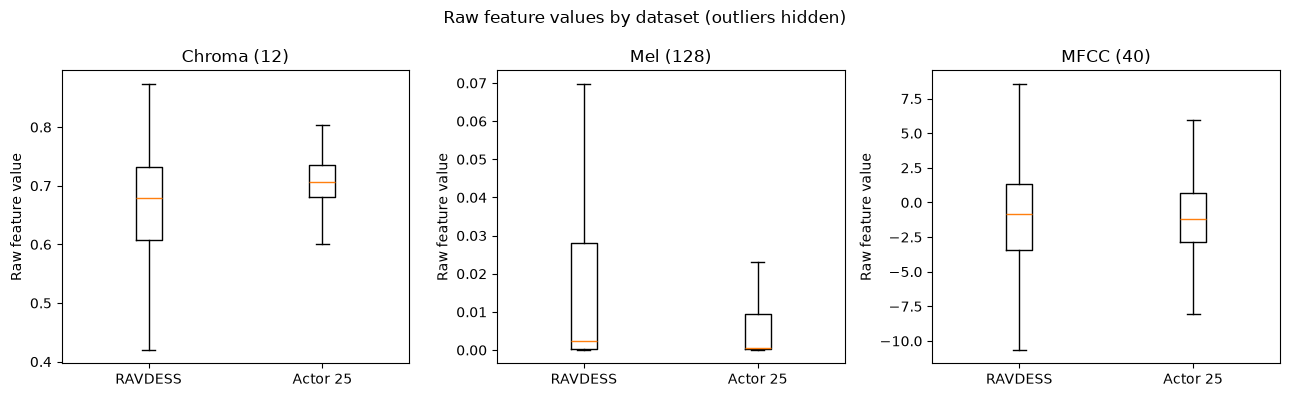

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (group, section) in zip(axes, feature_groups.items()):
    ax.boxplot([X_ravdess[:, section].ravel(), X_actor25[:, section].ravel()],
               tick_labels=['RAVDESS', 'Actor 25'], showfliers=False)
    ax.set_title(group)
    ax.set_ylabel('Raw feature value')
fig.suptitle('Raw feature values by dataset (outliers hidden)')
plt.tight_layout()
plt.savefig('results/feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

## Train and compare classifiers

I compare the tutorial classifiers and add Logistic Regression as one extra baseline. Each classifier uses the same RAVDESS train/test rows under raw, StandardScaler, and MinMaxScaler features. Accuracy and macro-F1 are reported on the RAVDESS holdout and on all Actor 25 recordings. The personal recordings remain an external test set; they are not used to train the models.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

classifiers = {
    'kNN': KNeighborsClassifier(),
    'SVM linear': SVC(kernel='linear'),
    'SVM RBF': SVC(kernel='rbf'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gaussian NB': GaussianNB(),
    'PCA + QDA': make_pipeline(
        PCA(n_components=40, random_state=42),
        QuadraticDiscriminantAnalysis(reg_param=0.1)
    ),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42)
}

feature_versions = {
    'Unscaled': (X_train, X_test, X_actor25),
    'Standard': (standard_scaler.transform(X_train),
                 standard_scaler.transform(X_test),
                 standard_scaler.transform(X_actor25)),
    'MinMax': (minmax_scaler.transform(X_train),
               minmax_scaler.transform(X_test),
               minmax_scaler.transform(X_actor25))
}

result_rows = []
for scale_name, (train_features, test_features, actor_features) in feature_versions.items():
    for model_name, classifier in classifiers.items():
        classifier.fit(train_features, y_train)
        for dataset_name, features_to_score, labels in [
            ('RAVDESS test', test_features, y_test),
            ('Actor 25', actor_features, y_actor25)
        ]:
            predictions = classifier.predict(features_to_score)
            result_rows.append({
                'Feature version': scale_name,
                'Classifier': model_name,
                'Test set': dataset_name,
                'Accuracy': accuracy_score(labels, predictions),
                'Macro-F1': f1_score(labels, predictions, average='macro', zero_division=0)
            })

results = pd.DataFrame(result_rows)
results[['Accuracy', 'Macro-F1']] = results[['Accuracy', 'Macro-F1']].round(3)
results.to_csv('results/classification_metrics.csv', index=False)
display(results.pivot(index='Classifier', columns=['Feature version', 'Test set'], values='Accuracy'))
display(results.pivot(index='Classifier', columns=['Feature version', 'Test set'], values='Macro-F1'))

  File "/Users/allannnnn/Documents/Codex/2026-09-24/this-assignment-aims-to-deepen-your/work/a3-venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 264, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/allannnnn/Documents/Codex/2026-09-24/this-assignment-aims-to-deepen-your/work/a3-venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 420, in _count_physical_cores_darwin
    return int(cpu_info)
           ^^^^^^^^^^^^^


Feature version         Unscaled              Standard                MinMax  \
Test set            RAVDESS test Actor 25 RAVDESS test Actor 25 RAVDESS test   
Classifier                                                                     
AdaBoost                   0.361    0.150        0.372    0.117        0.372   
Decision Tree              0.389    0.083        0.378    0.083        0.375   
Gaussian NB                0.319    0.133        0.302    0.083        0.302   
Logistic Regression        0.472    0.267        0.490    0.133        0.493   
PCA + QDA                  0.528    0.133        0.372    0.167        0.420   
Random Forest              0.545    0.183        0.531    0.183        0.535   
SVM RBF                    0.306    0.167        0.507    0.150        0.434   
SVM linear                 0.490    0.133        0.531    0.100        0.503   
kNN                        0.458    0.200        0.556    0.217        0.566   

Feature version               
Test set            Actor 25  
Classifier                    
AdaBoost               0.117  
Decision Tree          0.133  
Gaussian NB            0.083  
Logistic Regression    0.133  
PCA + QDA              0.150  
Random Forest          0.167  
SVM RBF                0.150  
SVM linear             0.133  
kNN                    0.217

Feature version         Unscaled              Standard                MinMax  \
Test set            RAVDESS test Actor 25 RAVDESS test Actor 25 RAVDESS test   
Classifier                                                                     
AdaBoost                   0.316    0.097        0.309    0.068        0.309   
Decision Tree              0.383    0.058        0.372    0.083        0.373   
Gaussian NB                0.278    0.029        0.273    0.056        0.273   
Logistic Regression        0.466    0.172        0.472    0.029        0.448   
PCA + QDA                  0.501    0.029        0.358    0.080        0.362   
Random Forest              0.520    0.113        0.500    0.110        0.502   
SVM RBF                    0.200    0.068        0.451    0.090        0.375   
SVM linear                 0.490    0.073        0.526    0.024        0.464   
kNN                        0.427    0.099        0.527    0.129        0.545   

Feature version               
Test set            Actor 25  
Classifier                    
AdaBoost               0.068  
Decision Tree          0.134  
Gaussian NB            0.056  
Logistic Regression    0.029  
PCA + QDA              0.058  
Random Forest          0.066  
SVM RBF                0.058  
SVM linear             0.029  
kNN                    0.135

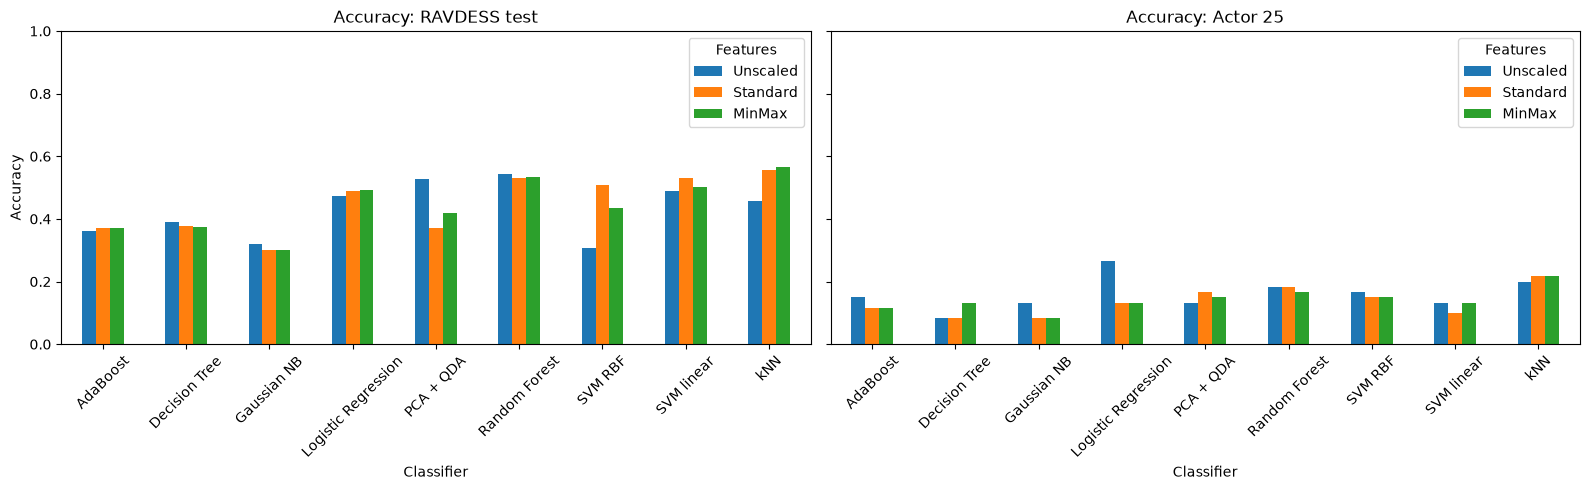

Best RAVDESS test result: {'Feature version': 'MinMax', 'Classifier': 'kNN', 'Test set': 'RAVDESS test', 'Accuracy': 0.566, 'Macro-F1': 0.545}
Best Actor 25 result: {'Feature version': 'Unscaled', 'Classifier': 'Logistic Regression', 'Test set': 'Actor 25', 'Accuracy': 0.267, 'Macro-F1': 0.172}


In [7]:
# Plot accuracy for the two test sets; bars use the same blue/standard notebook style.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, test_set in zip(axes, ['RAVDESS test', 'Actor 25']):
    subset = results[results['Test set'] == test_set]
    chart = subset.pivot(index='Classifier', columns='Feature version', values='Accuracy')
    chart = chart[['Unscaled', 'Standard', 'MinMax']]
    chart.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(f'Accuracy: {test_set}')
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Features')
plt.tight_layout()
plt.savefig('results/classification_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

best_actor = results[results['Test set'] == 'Actor 25'].sort_values(
    ['Accuracy', 'Macro-F1'], ascending=False
).iloc[0]
best_ravdess = results[results['Test set'] == 'RAVDESS test'].sort_values(
    ['Accuracy', 'Macro-F1'], ascending=False
).iloc[0]
print('Best RAVDESS test result:', best_ravdess.to_dict())
print('Best Actor 25 result:', best_actor.to_dict())

## Notes

Actor 25 has one speaker, whereas RAVDESS contains many actors and more recordings per class. A difference between the two scores can reflect speaker, microphone/room, delivery, and recording setup differences as well as emotion cues. Because Actor 25 is one person's recordings, its score should not be treated as a general measure across speakers. Results are accuracy on the RAVDESS held-out split and macro-F1/accuracy on both test sets; no external recording was included in training.

## References

- Livingstone, S. R., & Russo, F. A. (2018). The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS). *PLOS ONE*, 13(5), e0196391. https://doi.org/10.1371/journal.pone.0196391
- IAT-ExploringAI-2026. *Week3-ClassicML: Week 3 Machine Learning notebook and Assignment 3 instructions*. https://github.com/IAT-ExploringAI-2026/Week3-ClassicML
- Librosa documentation. https://librosa.org/doc/latest/
- scikit-learn documentation. https://scikit-learn.org/stable/
- SoundFile documentation. https://python-soundfile.readthedocs.io/